In [2]:
import os
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

from utils.model_io import load_model
from utils.comparison.comparison import *

cur_dir = Path(os.getcwd()).resolve()
proj_dir = next(parent for parent in [cur_dir, *cur_dir.parents] if (parent / "utils").exists() and (parent / "data").exists())

MODELS_DIR = proj_dir / "saved_models" / "task_2"
DATA_PATH = proj_dir / "data" / "split" / "task_2"
SAVE_PLOT_PATH = proj_dir / "doc" / "src" / "models"
SAVE = True

# Comparison of the deep learning models (Task 2)
import the best models and use the trained models to all subjects provided, in order to see whether the model is able to generalize


## 1. Load best models find for the task
Searches the 'saved_models' directory for the best-performing model. It extracts the subject ID and algorithm name from the filename to contextualize the cross-subject test.

In [3]:
# find all available best models
model_files = list(MODELS_DIR.glob("*.joblib"))
if not model_files:
    raise FileNotFoundError(f"No models found in {MODELS_DIR}")
# select one model
model_path = model_files[1] 

# extract metadata from the model filename (format: chbNN_ModelName_best_model.joblib)
model_filename = model_path.stem
SELECTED_SUBJECT = model_filename.split("_")[0]
MODEL_TYPE = model_filename.split("_")[1]

print(f"COMPARISON OF:")
print(f"\tModel Path: {model_path}")
print(f"\tTrained on: {SELECTED_SUBJECT} ({MODEL_TYPE})")

# load model object
model = load_model(model_path)

COMPARISON OF:
	Model Path: C:\Users\aless\Desktop\EEG-epileptic-seizures-detection\saved_models\task_2\chb12_RecurrentNet_best_model.joblib
	Trained on: chb12 (RecurrentNet)


## 2. Load data of the subjects
Defines the helper function to load and 'pool' recordings and extract the subjects data from the files.

In [4]:
def load_and_pool_subject(subj_id):
    """
    Loads all .npz files for a specific subject and pools all channels together 
    as separate samples to match the Task 2 training logic.
    """
    subj_path = DATA_PATH / subj_id
    files = sorted(list(subj_path.glob("*.npz")))
    
    all_pooled_frames = []
    
    for f_path in files:
        data = np.load(f_path, allow_pickle=True)
        
        channels = data["channels"]
        feature_names = data["feature_names"]
        
        # 1. Identify base feature names by removing the prefix of the first channel
        # This ensures column alignment across all pooled channels
        first_ch = str(channels[0])
        base_names = [name.replace(f"{first_ch}_", "") for name in feature_names if name.startswith(f"{first_ch}_")]
        
        file_channel_frames = []
        
        # 2. Iterate through each channel to "explode" the samples
        for ch_name in channels:
            ch_name = str(ch_name)
            # Find indices belonging to this specific channel
            idx = [i for i, name in enumerate(feature_names) if name.startswith(f"{ch_name}_")]
            
            if len(idx) == 0:
                continue
            
            # 3. Extract the test split for this channel
            X_test_ch = data["X_test"][:, idx]
            y_test_ch = data["y_test"]
            
            # Create a DataFrame with generic feature names (no channel prefix)
            df_ch = pd.DataFrame(X_test_ch, columns=base_names)
            df_ch["is_seizure"] = np.asarray(y_test_ch).astype(int)
            
            # Optional: Uncomment if you need to track channel source during evaluation
            # df_ch["original_channel"] = ch_name 
            
            file_channel_frames.append(df_ch)
            
        # Combine all channels for this specific file
        if file_channel_frames:
            all_pooled_frames.append(pd.concat(file_channel_frames, ignore_index=True))
            
    # Combine all pooled files into one single subject DataFrame
    if not all_pooled_frames:
        raise ValueError(f"No data found for subject {subj_id}")
        
    full_subject_df = pd.concat(all_pooled_frames, ignore_index=True)
    
    return full_subject_df

In [5]:
# map subjects and their respective files
# Dict format: {'chb01': [file1, file2...], 'chb02': [...]}
SUBJECTS_DIRECTORIES = {
    subj.name: sorted([f.stem for f in subj.glob("*.npz")])
    for subj in DATA_PATH.iterdir() if subj.is_dir()
}

## 3. Perform cross-subject evaluation
Iterates through every subject in the dataset. For each subject: performs data preprocessing (scaling and feature selection), generates predictions, and calculates metrics focused on seizure detection accuracy (Recall, Precision, and F1-score).

In [6]:
print(f"\nStarting cross-subject evaluation...")
results = []
eval_data = {}

for subj_name in tqdm(SUBJECTS_DIRECTORIES.keys(), desc="Evaluating Subjects"):
    try:
        print(f"\nLoading subject {subj_name} recordings...")
        df_subj = load_and_pool_subject(subj_name)

        # preprocess data
        X, y = model.preprocess(df_subj, is_training=False, verbose=True)

        # make predictions
        y_pred = model.predict(X)
        scores = model.predict_proba(X) if hasattr(model, 'predict_proba') else None

        # store data for confusion matrix
        eval_data[subj_name] = {"y_true": y, "y_pred": y_pred}

        results.append({
            "subject": subj_name,
            "samples": len(y),
            "seizure_samples": np.sum(y),
            "accuracy": accuracy_score(y, y_pred),
            "precision": precision_score(y, y_pred, average="weighted", zero_division=0),
            "recall": recall_score(y, y_pred, average="weighted", zero_division=0),
            "f1": f1_score(y, y_pred, average="weighted", zero_division=0),
            "precision_seizure": precision_score(y, y_pred, pos_label=1, zero_division=0),
            "recall_seizure": recall_score(y, y_pred, pos_label=1, zero_division=0),
            "f1_seizure": f1_score(y, y_pred, pos_label=1, zero_division=0),
            "roc_auc": np.nan,
        })

        if scores is not None and len(np.unique(y)) == 2:
            results["roc_auc"] = roc_auc_score(y, scores)
    except Exception as e:
        print(f"Error evaluating {subj_name}: {e}")



Starting cross-subject evaluation...


Evaluating Subjects:   0%|          | 0/4 [00:00<?, ?it/s]


Loading subject chb04 recordings...
[LSTM] Features shape: (85920, 18), Labels shape: (85920,)
Label distribution:
0    1.0
Name: proportion, dtype: float64


predict:   0%|          | 0/672 [00:00<?, ?it/s]

predict:   0%|          | 0/672 [00:00<?, ?it/s]

...

predict:   0%|          | 0/337 [00:00<?, ?it/s]

Error evaluating chb13: list indices must be integers or slices, not str

Loading subject chb19 recordings...
[LSTM] Features shape: (16146, 18), Labels shape: (16146,)
Label distribution:
0    0.777778
1    0.222222
Name: proportion, dtype: float64


predict:   0%|          | 0/127 [00:00<?, ?it/s]

predict:   0%|          | 0/127 [00:00<?, ?it/s]

Error evaluating chb19: list indices must be integers or slices, not str


In [7]:
results_df = pd.DataFrame(results).set_index("subject")
display(results_df)

,samples,seizure_samples,accuracy,precision,recall,f1,precision_seizure,recall_seizure,f1_seizure,roc_auc
subject,,,,,,,,,,
chb04,85920,0,0.494914,1.000000,0.494914,0.662130,0.000000,0.000000,0.000000,NaN
chb12,54489,3302,0.723375,0.910402,0.723375,0.794285,0.117054,0.544821,0.192705,NaN
chb13,43098,2964,0.467145,0.902178,0.467145,0.578301,0.092099,0.761808,0.164332,NaN
chb19,16146,3588,0.668215,0.755907,0.668215,0.693930,0.361342,0.642419,0.462526,NaN


## 4. Cross Subject Comparison

### Confusion Matrices
Generates a row of confusion matrices, one for each subject. This allows for a granular look at False Alarms (False Positives) versus Missed Seizures (False Negatives) across the entire cohort.

Evaluating Subjects:   0%|          | 0/4 [00:00<?, ?it/s]

--- Class Distribution - chb04 ---
Class 0.0: 4010 samples (100.00%)


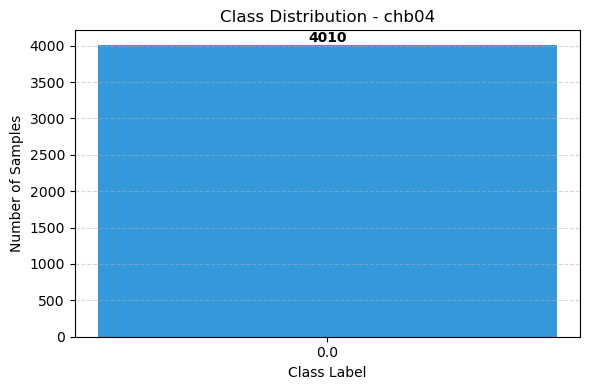

--- Class Distribution - chb12 ---
Class 0.0: 1936 samples (93.84%)
Class 1.0: 127 samples (6.16%)


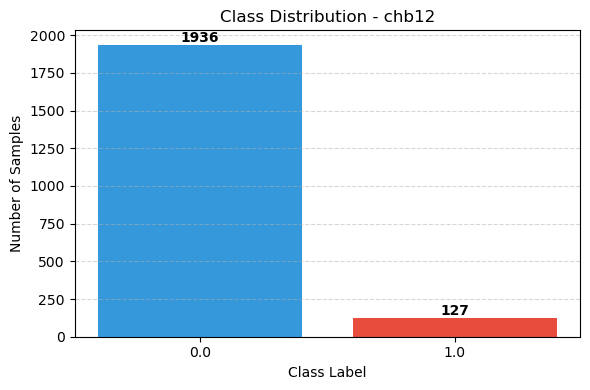

--- Class Distribution - chb13 ---
Class 0.0: 1584 samples (93.29%)
Class 1.0: 114 samples (6.71%)


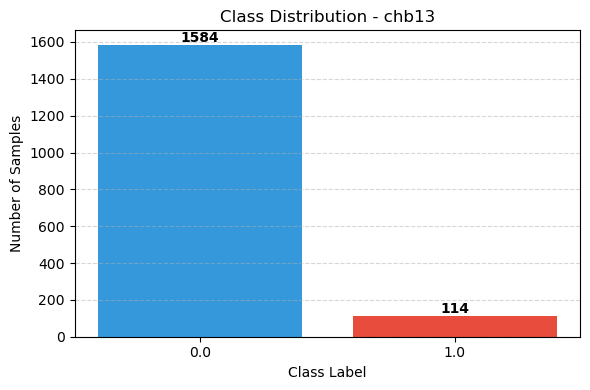

--- Class Distribution - chb19 ---
Class 0.0: 483 samples (77.78%)
Class 1.0: 138 samples (22.22%)


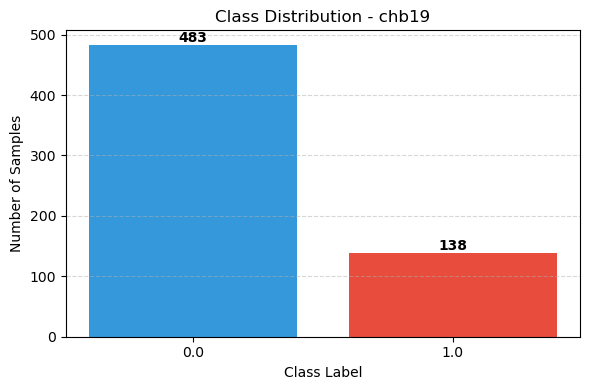

In [8]:
from utils.exploration.processed_data import get_agglomerated_labels, plot_class_distribution

for subj_name in tqdm(SUBJECTS_DIRECTORIES.keys(), desc="Evaluating Subjects"):
    # store data to explore label distribution
    subj_files = [DATA_PATH / subj_name / f"{f}.npz" for f in SUBJECTS_DIRECTORIES[subj_name]]
    y_labels_total = get_agglomerated_labels(subj_files, label_key='y_test')

    plot_class_distribution(
            labels=y_labels_total, 
            title=f'Class Distribution - {subj_name}',
            save=False,
        )

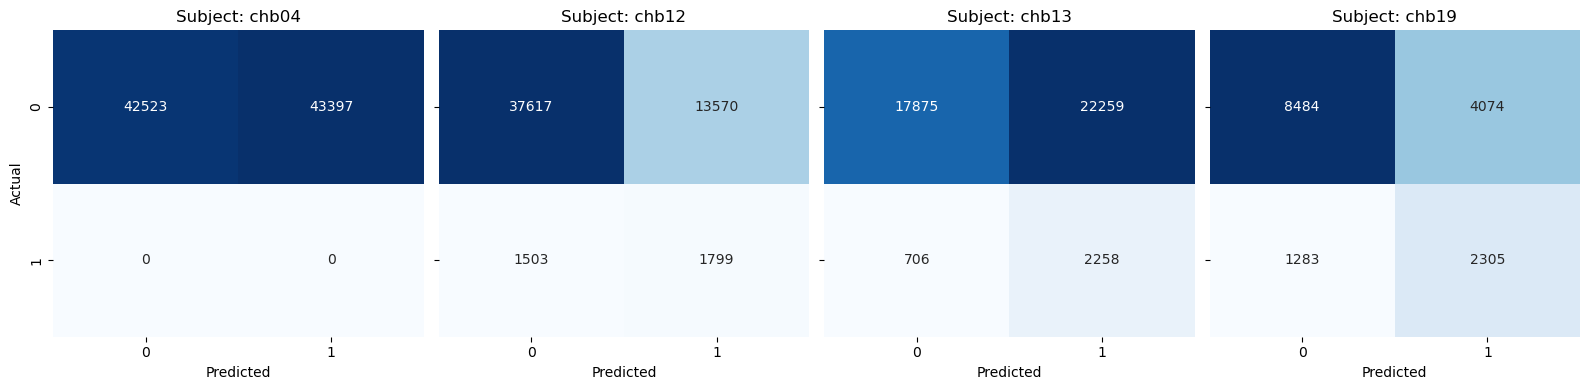

In [9]:

plot_all_confusion_matrices(eval_data, save=SAVE, path=SAVE_PLOT_PATH / "task2d_comparison_confusion_matrices.png")

> These are realistic recordings. Since we use the final 15% of each patient's data for testing, many subjects have few seizures and then few Pre-Ictal windows in this period. This explains the strong class imbalance in the confusion matrices. The model currently shows a strong bias toward **False Positives**, which in a real-world scenario would cause unnecessary patient stress by signaling "phantom" seizures. Conversely, the light presence of **False Negatives** is a critical safety concern, as the system fails to warn the subject of an impending attack. While the model establishes a baseline, the trade-off between sensitivity and the false alarm rate needs further optimization to be clinically viable.

### Cross-Subject Generalization Heatmap
Visualizes all performance metrics across all subjects in a single heatmap. This facilitates the identification of subjects where the model performance degrades, highlighting the limits of the model's generalization.

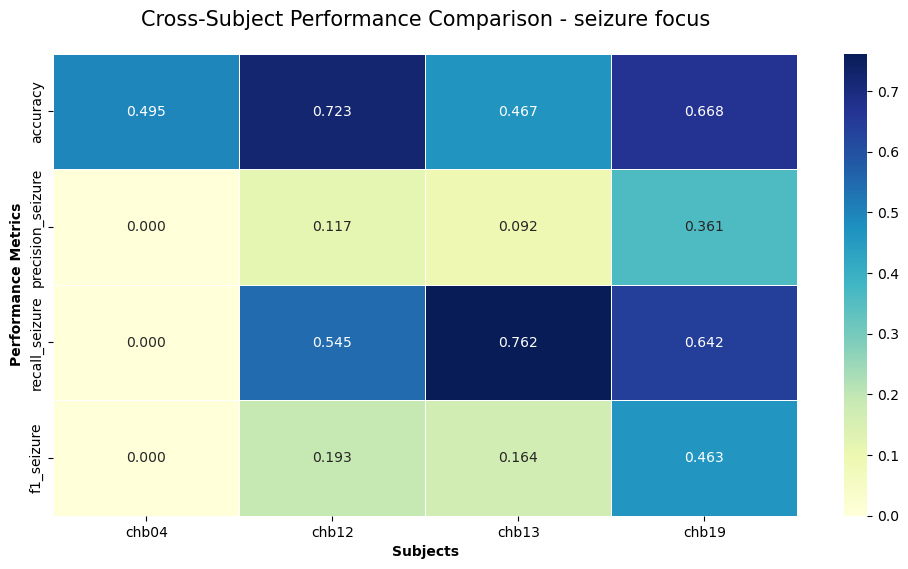

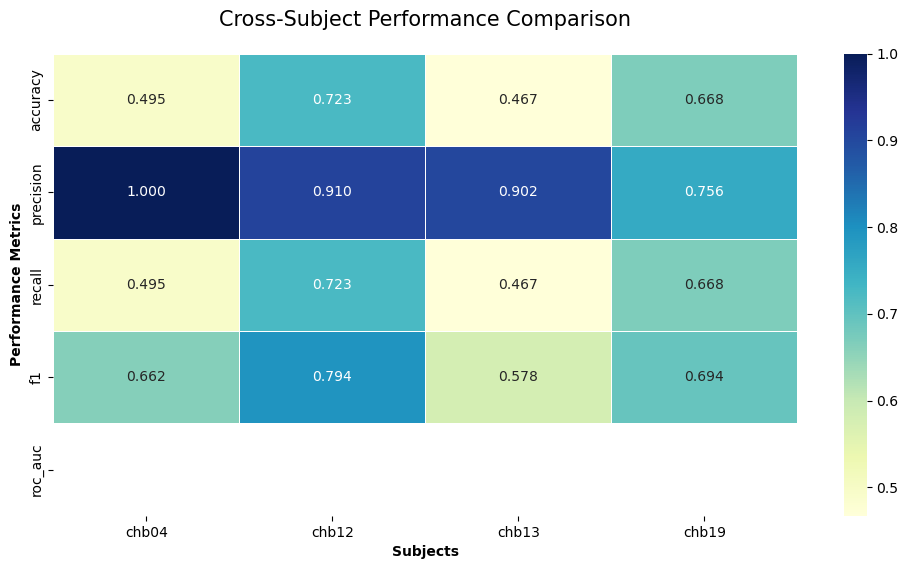

In [10]:
plot_subjects_metrics_heatmap(results_df, metrics_cols=["accuracy", "precision_seizure", "recall_seizure", "f1_seizure"], title = "Cross-Subject Performance Comparison - seizure focus")
plot_subjects_metrics_heatmap(results_df, save=SAVE, path=SAVE_PLOT_PATH / "task2d_comparison_metrics_heatmap.png")

- The first heatmap shows poor results for the seizure class because it focuses strictly on the Pre-Ictal windows. While Accuracy remains high (due to the abundance of normal data), Precision and F1-score are very low, indicating a high number of False Positives (False Alarms). The Recall, however, is slightly higher than the other metrics; this is because the model is "aggressive" in predicting seizures (it catches several real pre-ictal windows, but at the cost of triggering many false warnings during normal activity).

- The second heatmap provides a more balanced view of the model's overall reliability. Here, we can see that the **Precision is significantly higher (around 0.90 in the majority of the subjects)**, which **positively affects the F1-score**. This means that when the model considers the entire recording (including the vast majority of normal activity) it is very accurate at not misclassifying the "Normal" state.

The model generalizes best on `chb12` (Female, 2y), our training subject. Completely unexpected, despite the similar age and same sex, the performance drops significantly for `chb13` (Female, 3y). This suggests that the model does _not generalize effectively across similar subjects_, even in early childhood where EEG morphology is generally consistent. This indicates that seizure forecasting may be ***highly dependent on individual-specific "pre-seizure signatures" rather than general age-related brain patterns***. 

Conversely, this model performs relatively better on `chb19` (Female, 19y) compared to other non-training subjects. In contrast, it performs very poorly on `chb04` (Male, 22y). 

> We can conclude that ***Task 2 (Forecasting) is significantly more sensitive to gender and specific brain maturation than Task 1***. A model trained on a toddler (`chb12`) seems to retain some predictive power for a young female adult (`chb19`) but fails completely for a male adult (`chb04`), likely due to the vast differences in EEG amplitude and frequency distribution between these two demographics.

While the global **Precision is strong at 0.90** and other weighted metrics **hover around 0.70**, the model still **struggles with the specific "Pre-Ictal vs. Inter-Ictal" discrimination**. It is excellent at recognizing stability, but it needs further refinement, possibly through subject-specific calibration, to reduce false alarms and improve the specific detection of the 10-minute pre-seizure window.